# 02 — Convergence Prediction

Task: classify whether a solver will converge on a given matrix.

Sections:
1. Baseline models — LogReg vs RF, Tier-1 vs Tier-1+2
2. Boruta feature selection on `converged_clean`
3. Retrain RF on Boruta-selected features
4. SHAP analysis — global importance + local waterfall

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance
from boruta import BorutaPy

df = pd.read_csv('../data/processed/ml_dataset_full.csv')
print('Dataset:', df.shape)

TIER1_COLS = [
    'nrows','ncols','nnz','density',
    'nnz_per_row_mean','nnz_per_row_std','nnz_per_row_min','nnz_per_row_max',
    'zero_diag_fraction','diag_abs_mean','diag_abs_std','diag_dominance_fraction',
    'norm_1','norm_inf','symmetry_score_struct'
]
TIER2_COLS = [
    'row_norm2_mean','row_norm2_std','row_norm2_min','row_norm2_max',
    'col_norm2_mean','col_norm2_std','col_norm2_min','col_norm2_max',
    'diag_abs_min','diag_abs_max','tiny_diag_fraction',
    'symmetry_numeric_fro_ratio','spec_radius_est',
    'sigma_max_est_power','row_norm2_spread','pseudo_kappa'
]
LOG_FEATURES = [
    'pseudo_kappa','spec_radius_est','sigma_max_est_power','row_norm2_spread',
    'norm_inf','norm_1','row_norm2_mean','row_norm2_std','row_norm2_max',
    'col_norm2_mean','col_norm2_std','col_norm2_max'
]

def build_X(df_in, use_tier2=True):
    """Build feature matrix with consistent log-transforms and solver one-hot encoding."""
    solver_dummies = pd.get_dummies(df_in[['ksp','pc']], drop_first=False)
    cols = TIER1_COLS + (TIER2_COLS if use_tier2 else [])
    cols = [c for c in cols if c in df_in.columns]
    X = df_in[cols].copy()
    for f in LOG_FEATURES:
        if f in X.columns:
            X[f] = np.log10(X[f].clip(lower=1e-30))
    return pd.concat([solver_dummies.reset_index(drop=True),
                      X.reset_index(drop=True)], axis=1)

y = df['converged_clean'].astype(int)
X_t1  = build_X(df, use_tier2=False)
X_t12 = build_X(df, use_tier2=True)

# Grouped split — same matrix never in both train and test
gss = GroupShuffleSplit(test_size=0.25, random_state=0)
train_idx, test_idx = next(gss.split(X_t12, y, groups=df['matrix_id']))

X1_tr,  X1_te  = X_t1.iloc[train_idx],  X_t1.iloc[test_idx]
X12_tr, X12_te = X_t12.iloc[train_idx], X_t12.iloc[test_idx]
y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]
print('Train:', len(y_tr), '| Test:', len(y_te))
print('Unique matrices — train:', df.iloc[train_idx]['matrix_id'].nunique(),
      '| test:', df.iloc[test_idx]['matrix_id'].nunique())

Dataset: (6392, 47)
Train: 4792 | Test: 1600
Unique matrices — train: 599 | test: 200


## 1 · Baseline models

In [13]:
def make_logreg():
    return Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('scl', StandardScaler()),
        ('clf', LogisticRegression(max_iter=5000, class_weight='balanced'))
    ])

def make_rf():
    return Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('clf', RandomForestClassifier(n_estimators=400, random_state=42,
                                       class_weight='balanced', n_jobs=-1))
    ])

results = {}
for name, model, Xtr, Xte in [
    ('LogReg  Tier-1',   make_logreg(), X1_tr,  X1_te),
    ('LogReg  Tier-1+2', make_logreg(), X12_tr, X12_te),
    ('RF      Tier-1',   make_rf(),     X1_tr,  X1_te),
    ('RF      Tier-1+2', make_rf(),     X12_tr, X12_te),
]:
    model.fit(Xtr, y_tr)
    pred = model.predict(Xte)
    results[name] = model
    print(f'\n=== {name} ===')
    print(classification_report(y_te, pred, digits=3))


=== LogReg  Tier-1 ===
              precision    recall  f1-score   support

           0      0.906     0.752     0.821      1276
           1      0.414     0.691     0.518       324

    accuracy                          0.739      1600
   macro avg      0.660     0.721     0.670      1600
weighted avg      0.806     0.739     0.760      1600


=== LogReg  Tier-1+2 ===
              precision    recall  f1-score   support

           0      0.908     0.755     0.825      1276
           1      0.420     0.698     0.524       324

    accuracy                          0.744      1600
   macro avg      0.664     0.727     0.674      1600
weighted avg      0.809     0.744     0.764      1600


=== RF      Tier-1 ===
              precision    recall  f1-score   support

           0      0.910     0.962     0.935      1276
           1      0.808     0.623     0.704       324

    accuracy                          0.894      1600
   macro avg      0.859     0.793     0.820      1600


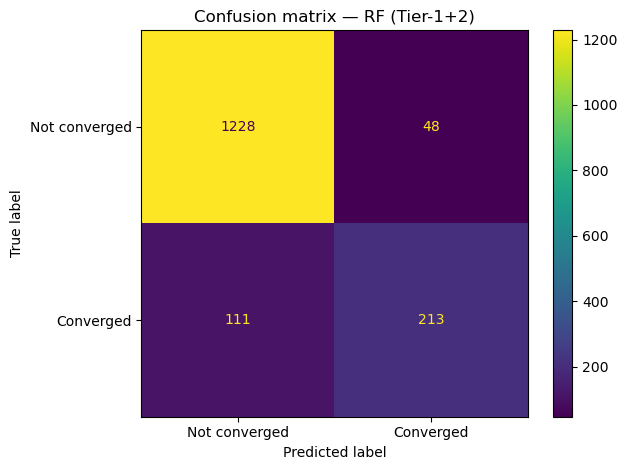

In [14]:
# Confusion matrix — best model (RF Tier-1+2)
best = results['RF      Tier-1+2']
pred_best = best.predict(X12_te)
ConfusionMatrixDisplay.from_predictions(y_te, pred_best,
    display_labels=['Not converged', 'Converged'])
plt.title('Confusion matrix — RF (Tier-1+2)')
plt.tight_layout()
plt.show()

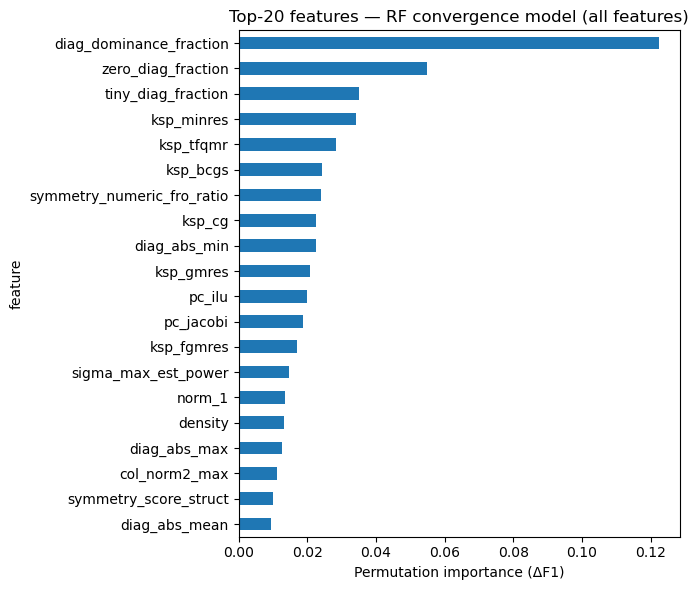

                   feature  importance
   diag_dominance_fraction    0.122417
        zero_diag_fraction    0.054886
        tiny_diag_fraction    0.034994
                ksp_minres    0.034071
                 ksp_tfqmr    0.028276
                  ksp_bcgs    0.024198
symmetry_numeric_fro_ratio    0.024021
                    ksp_cg    0.022614
              diag_abs_min    0.022457
                 ksp_gmres    0.020797


In [15]:
# Permutation importance — full pipeline, no warning
perm = permutation_importance(best, X12_te, y_te,
                               n_repeats=20, random_state=42, scoring='f1')
imp_df = (pd.DataFrame({'feature': X12_te.columns,
                         'importance': perm.importances_mean})
            .sort_values('importance', ascending=False))

fig, ax = plt.subplots(figsize=(7, 6))
imp_df.head(20).sort_values('importance').plot(
    kind='barh', x='feature', y='importance', ax=ax, legend=False)
ax.set_xlabel('Permutation importance (ΔF1)')
ax.set_title('Top-20 features — RF convergence model (all features)')
plt.tight_layout()
plt.show()
print(imp_df.head(10).to_string(index=False))

## 2 · Boruta feature selection

Boruta compares each feature against randomly permuted 'shadow' copies. Only features that consistently outperform the best shadow feature are confirmed as relevant.

In [16]:
# Prepare clean matrix for Boruta: imputed, no inf
X_imp = X_t12.copy().fillna(X_t12.median(numeric_only=True))
X_imp = X_imp.replace([np.inf, -np.inf], 0)
y_arr = y.values

boruta_rf = RandomForestClassifier(
    n_estimators=100, class_weight='balanced', random_state=0, n_jobs=-1)

boruta = BorutaPy(
    estimator=boruta_rf,
    n_estimators='auto',
    perc=100,       # strict: must beat the best shadow feature
    alpha=0.05,
    max_iter=150,
    random_state=0,
    verbose=1
)
boruta.fit(X_imp.values, y_arr)

ranking = pd.DataFrame({
    'feature':   X_imp.columns,
    'selected':  boruta.support_,
    'tentative': boruta.support_weak_,
    'rank':      boruta.ranking_
}).sort_values(['rank', 'feature'])

selected_conv = ranking[ranking['selected']]['feature'].tolist()
tentative_features = ranking[ranking['tentative']]['feature'].tolist()

if len(selected_conv) == 0:
    print('WARNING: Boruta selected 0 features — falling back to top-10 by rank.')
    selected_conv = ranking.head(10)['feature'].tolist()

print(f'\nSelected ({len(selected_conv)}): {selected_conv}')
print(f'Tentative: {tentative_features}')
display(ranking.head(20))

Iteration: 1 / 150
Iteration: 2 / 150
Iteration: 3 / 150
Iteration: 4 / 150
Iteration: 5 / 150
Iteration: 6 / 150
Iteration: 7 / 150
Iteration: 8 / 150
Iteration: 9 / 150
Iteration: 10 / 150
Iteration: 11 / 150
Iteration: 12 / 150
Iteration: 13 / 150
Iteration: 14 / 150
Iteration: 15 / 150
Iteration: 16 / 150
Iteration: 17 / 150
Iteration: 18 / 150
Iteration: 19 / 150
Iteration: 20 / 150
Iteration: 21 / 150
Iteration: 22 / 150
Iteration: 23 / 150
Iteration: 24 / 150
Iteration: 25 / 150
Iteration: 26 / 150
Iteration: 27 / 150
Iteration: 28 / 150
Iteration: 29 / 150
Iteration: 30 / 150
Iteration: 31 / 150
Iteration: 32 / 150
Iteration: 33 / 150
Iteration: 34 / 150
Iteration: 35 / 150
Iteration: 36 / 150
Iteration: 37 / 150
Iteration: 38 / 150
Iteration: 39 / 150
Iteration: 40 / 150
Iteration: 41 / 150
Iteration: 42 / 150
Iteration: 43 / 150
Iteration: 44 / 150
Iteration: 45 / 150
Iteration: 46 / 150
Iteration: 47 / 150
Iteration: 48 / 150
Iteration: 49 / 150
Iteration: 50 / 150
Iteration

,feature,selected,tentative,rank
30,col_norm2_max,True,False,1
27,col_norm2_mean,True,False,1
29,col_norm2_min,True,False,1
28,col_norm2_std,True,False,1
11,density,True,False,1
32,diag_abs_max,True,False,1
17,diag_abs_mean,True,False,1
31,diag_abs_min,True,False,1
18,diag_abs_std,True,False,1
19,diag_dominance_fraction,True,False,1


## 3 · Retrain RF on Boruta-selected features

=== RF — Boruta-selected features (convergence) ===
              precision    recall  f1-score   support

           0      0.924     0.900     0.912      1276
           1      0.642     0.710     0.674       324

    accuracy                          0.861      1600
   macro avg      0.783     0.805     0.793      1600
weighted avg      0.867     0.861     0.864      1600

Using 30 features: ['col_norm2_max', 'col_norm2_mean', 'col_norm2_min', 'col_norm2_std', 'density', 'diag_abs_max', 'diag_abs_mean', 'diag_abs_min', 'diag_abs_std', 'diag_dominance_fraction', 'ncols', 'nnz', 'nnz_per_row_max', 'nnz_per_row_mean', 'nnz_per_row_std', 'norm_1', 'norm_inf', 'nrows', 'pc_ilu', 'pc_jacobi', 'pseudo_kappa', 'row_norm2_max', 'row_norm2_mean', 'row_norm2_min', 'row_norm2_spread', 'row_norm2_std', 'sigma_max_est_power', 'spec_radius_est', 'tiny_diag_fraction', 'zero_diag_fraction']


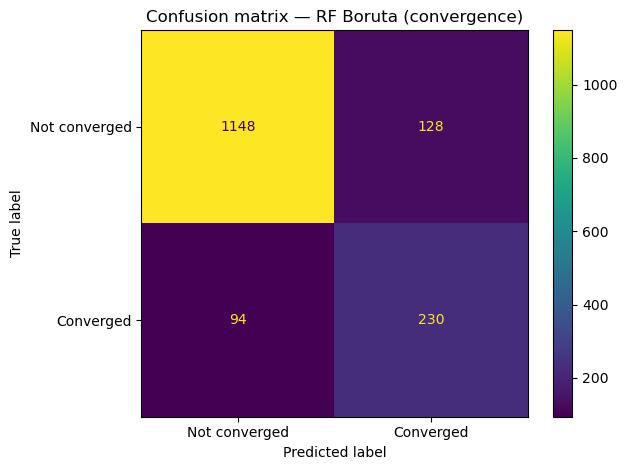

In [17]:
# Use the SAME train/test split and SAME imputed matrix as baseline
X_sel = X_imp[selected_conv]
X_sel_tr = X_sel.iloc[train_idx]
X_sel_te = X_sel.iloc[test_idx]

rf_boruta = RandomForestClassifier(
    n_estimators=500, random_state=0, class_weight='balanced', n_jobs=-1)
rf_boruta.fit(X_sel_tr, y_tr)
pred_boruta = rf_boruta.predict(X_sel_te)

print('=== RF — Boruta-selected features (convergence) ===')
print(classification_report(y_te, pred_boruta, digits=3))
print(f'Using {len(selected_conv)} features: {selected_conv}')

ConfusionMatrixDisplay.from_predictions(y_te, pred_boruta,
    display_labels=['Not converged', 'Converged'])
plt.title('Confusion matrix — RF Boruta (convergence)')
plt.tight_layout()
plt.show()

## 4 · SHAP analysis

SHAP (SHapley Additive exPlanations) explains each prediction by fairly distributing the model's output across features.

- **Beeswarm plot**: global view — which features matter most and in which direction
- **Waterfall plot**: local view — why the model made a specific prediction for one matrix

In [18]:
# Retrain on full data with selected features for SHAP (more stable explanations)
rf_shap = RandomForestClassifier(
    n_estimators=500, random_state=0, class_weight='balanced', n_jobs=-1)
rf_shap.fit(X_imp[selected_conv], y_arr)

explainer   = shap.TreeExplainer(rf_shap)
shap_values = explainer(X_imp[selected_conv])

# For binary classification TreeExplainer returns shape (n, features, 2)
# We take class=1 (converged)
sv = shap_values[..., 1] if shap_values.values.ndim == 3 else shap_values

print('SHAP values shape:', sv.values.shape)

SHAP values shape: (6392, 30)


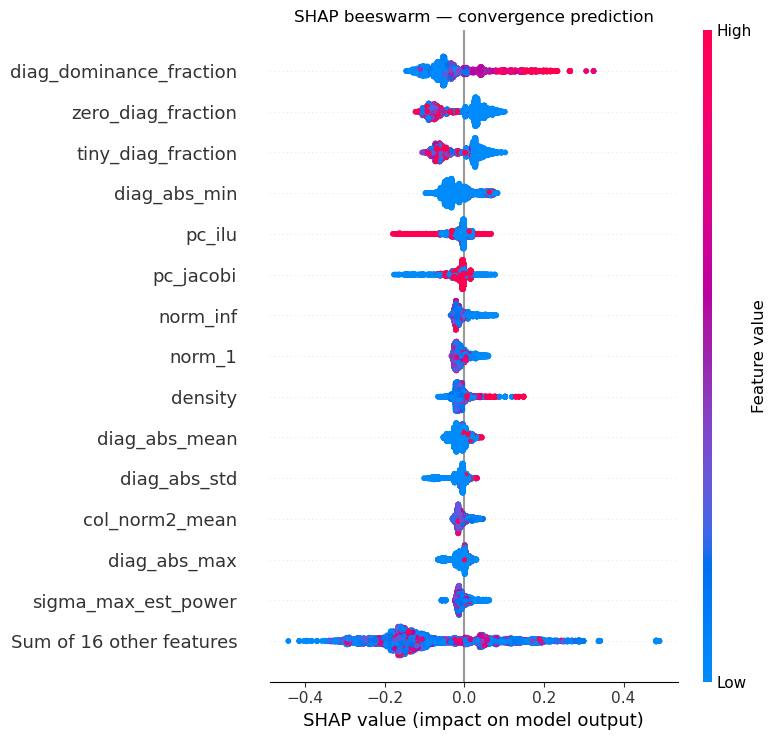

In [19]:
# Global beeswarm — feature impact across all samples
plt.figure()
shap.plots.beeswarm(sv, max_display=15, show=False)
plt.title('SHAP beeswarm — convergence prediction')
plt.tight_layout()
plt.show()

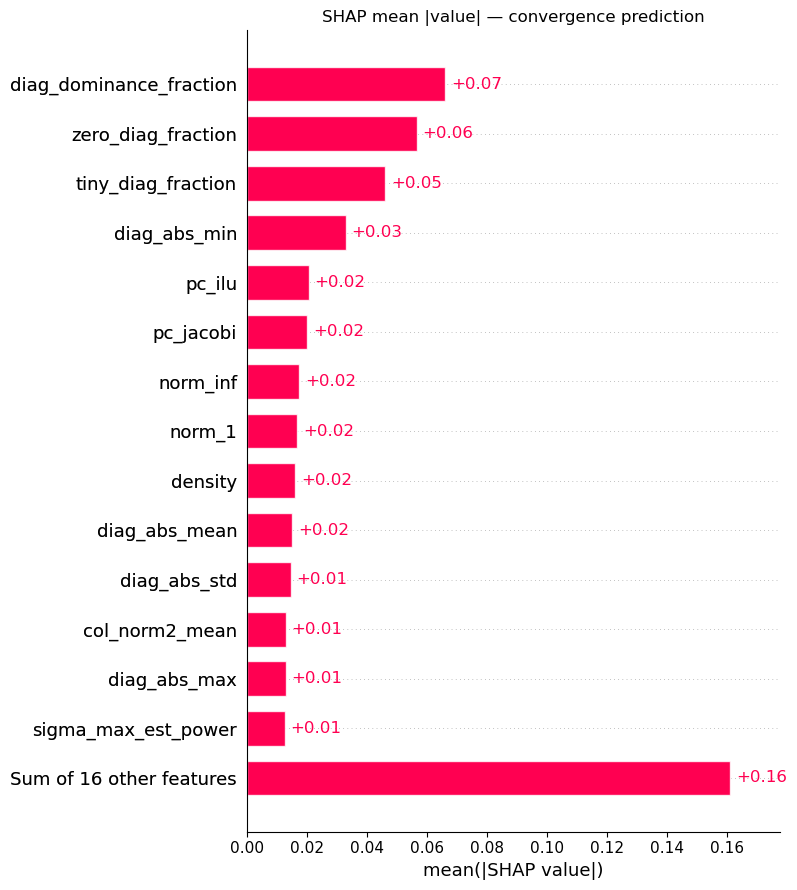

In [20]:
# Global bar — mean |SHAP| per feature
plt.figure()
shap.plots.bar(sv, max_display=15, show=False)
plt.title('SHAP mean |value| — convergence prediction')
plt.tight_layout()
plt.show()

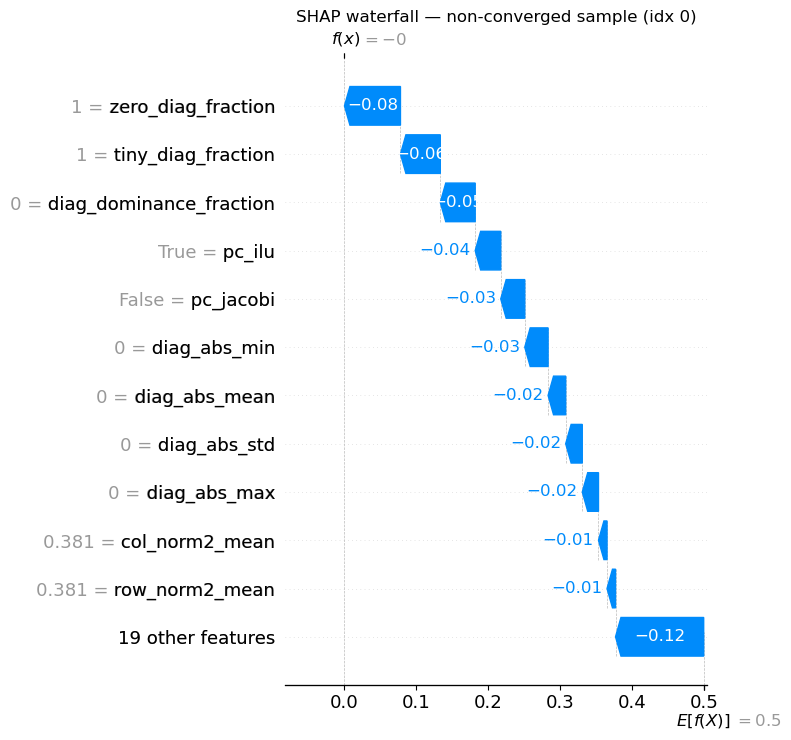

In [21]:
# Local waterfall — pick a non-converged sample and show why the model predicted it
non_conv_idx = np.where(y_arr == 0)[0]
if len(non_conv_idx) > 0:
    sample_idx = non_conv_idx[0]
    plt.figure()
    shap.plots.waterfall(sv[sample_idx], max_display=12, show=False)
    plt.title(f'SHAP waterfall — non-converged sample (idx {sample_idx})')
    plt.tight_layout()
    plt.show()
else:
    print('No non-converged samples found in this split.')